# Lab 8: Define and Solve an ML Problem of Your Choosing

In [1]:
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
import seaborn as sns

In this lab assignment, you will follow the machine learning life cycle and implement a model to solve a machine learning problem of your choosing. You will select a data set and choose a predictive problem that the data set supports.  You will then inspect the data with your problem in mind and begin to formulate a  project plan. You will then implement the machine learning project plan. 

You will complete the following tasks:

1. Build Your DataFrame
2. Define Your ML Problem
3. Perform exploratory data analysis to understand your data.
4. Define Your Project Plan
5. Implement Your Project Plan:
    * Prepare your data for your model.
    * Fit your model to the training data and evaluate your model.
    * Improve your model's performance.

## Part 1: Build Your DataFrame

You will have the option to choose one of four data sets that you have worked with in this program:

* The "census" data set that contains Census information from 1994: `censusData.csv`
* Airbnb NYC "listings" data set: `airbnbListingsData.csv`
* World Happiness Report (WHR) data set: `WHR2018Chapter2OnlineData.csv`
* Book Review data set: `bookReviewsData.csv`

Note that these are variations of the data sets that you have worked with in this program. For example, some do not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for each of the four data sets available to you.

<b>Task:</b> In the code cell below, use the same method you have been using to load the data using `pd.read_csv()` and save it to DataFrame `df`. 

You can load each file as a new DataFrame to inspect the data before choosing your data set.

In [2]:
# File names of the four data sets
adultDataSet_filename = os.path.join(os.getcwd(), "data", "censusData.csv")
airbnbDataSet_filename = os.path.join(os.getcwd(), "data", "airbnbListingsData.csv")
WHRDataSet_filename = os.path.join(os.getcwd(), "data", "WHR2018Chapter2OnlineData.csv")
bookReviewDataSet_filename = os.path.join(os.getcwd(), "data", "bookReviewsData.csv")


df = pd.read_csv(bookReviewDataSet_filename) # YOUR CODE HERE

df.head()

,Review,Positive Review
0,This was perhaps the best of Johannes Steinhof...,True
1,This very fascinating book is a story written ...,True
2,The four tales in this collection are beautifu...,True
3,The book contained more profanity than I expec...,False
4,We have now entered a second time of deep conc...,True


## Part 2: Define Your ML Problem

Next you will formulate your ML Problem. In the markdown cell below, answer the following questions:

1. List the data set you have chosen.
2. What will you be predicting? What is the label?
3. Is this a supervised or unsupervised learning problem? Is this a clustering, classification or regression problem? Is it a binary classificaiton or multi-class classifiction problem?
4. What are your features? (note: this list may change after your explore your data)
5. Explain why this is an important problem. In other words, how would a company create value with a model that predicts this label?

1. The data set I have chosen is the `bookReviewDataSet`.
2. I want to predict whether or not the review is positive, making the label `Positive Review` (basically sentiment analysis).
3. This is a supervised learning problem since it uses labeled data to train the model for predictions. It's a binary classification problem since each review is either labeled True (positive) or False (negative).
4. I only have one feature at the moment, `Review`, but there can be more if I create some for the sentiment analysis.
5. This is an important problem since a company can use it to decide what kind of books to keep selling/publishing, determine arbitrary ratings for the books, improve recommendation options, etc.

## Part 3: Understand Your Data

The next step is to perform exploratory data analysis. Inspect and analyze your data set with your machine learning problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * addressing missingness, such as replacing missing values with means
    * finding and replacing outliers
    * renaming features and labels
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * performing specific data cleaning and preprocessing techniques for an NLP problem
    * addressing class imbalance in your data sample to promote fair AI
    

2. What machine learning model (or models) you would like to use that is suitable for your predictive problem and data?
    * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 
 
3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics and methods that are appropriate for your model?
    

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. If you are working on a classification problem, use techniques you have learned to determine if there is class imbalance.

<b>Task</b>: Use the techniques you have learned in this course to inspect and analyze your data. You can import additional packages that you have used in this course that you will need to perform this task.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-drown menu.

In [3]:
# YOUR CODE HERE (df.head() already above)
df.describe()

,Review,Positive Review
count,1973,1973
unique,1865,2
top,I have read several of Hiaasen's books and lov...,False
freq,3,993


In [4]:
df['Review'].value_counts().head(5) # shows duplicate reviews with number of duplicates

I have read several of Hiaasen's books and loved them.  They were very funny.  This one is not.  It is an endless description of naked strippers.  I found the main character, Erin, to be very unappealing.  She is just so stupid.  Her problems are all of her own creation.  And she is not funny.  I think you have to be a man to like this book.  I, as a woman, just found it exceedingly boring.  I kept waiting for it to get funny.  It never did\n                                                                                                                                                                                                                                                                                                                3
How can a best-selling author like Simon Winchester take an event as exciting as the San Francisco Earthquake of 1906 and turn it into a tedious snooze-fest? One answer: write as if you had just discovered an adjective mine and were free to throw i

In [5]:
print("Columns and types:", df.dtypes, "\nShape of the data set", df.shape)

Columns and types: Review             object
Positive Review      bool
dtype: object 
Shape of the data set (1973, 2)


In [6]:
df.isna().sum() # don't need to replace NaN values because none

Review             0
Positive Review    0
dtype: int64

<__array_function__ internals>:5: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.


([<matplotlib.axis.XTick at 0x7f91d937fb80>,
 [Text(True, 0, '1'), Text(False, 0, '0')])

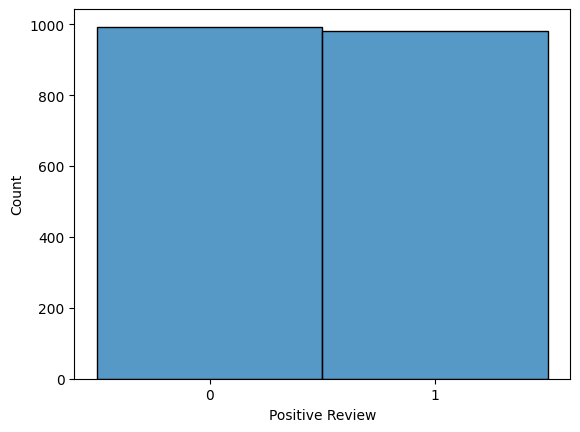

In [7]:
sns.histplot(data=df, x='Positive Review', discrete=True)
plt.xticks([True, False]) # shows a balanced label

There is no significant class imbalance, with nearly equal instances of positive and negative reviews.

## Part 4: Define Your Project Plan

Now that you understand your data, in the markdown cell below, define your plan to implement the remaining phases of the machine learning life cycle (data preparation, modeling, evaluation) to solve your ML problem. Answer the following questions:

* Do you have a new feature list? If so, what are the features that you chose to keep and remove after inspecting the data? 
* Explain different data preparation techniques that you will use to prepare your data for modeling.
* What is your model (or models)?
* Describe your plan to train your model, analyze its performance and then improve the model. That is, describe your model building, validation and selection plan to produce a model that generalizes well to new data. 

* I do not have a new feature list for this data set, since there is only one feature and there is no need to one-hot encode it.
* I will first drop any duplicate reviews before splitting the data into training and testing sets.
* My model will be a feedforward neural network that utilizes a TF-IDF vectorizer for NLP.
* I'm planning to first transform the text with the TF-IDF vectorizer before training the model on the split data. The model will be made up of 4 hidden layers, and I want to test the gelu activation function, so I will test different values wherever I can for my model, and I will decide the best through the graphs and data I generate for the loss and accuracy of my model.

## Part 5: Implement Your Project Plan

<b>Task:</b> In the code cell below, import additional packages that you have used in this course that you will need to implement your project plan.

In [8]:
# YOUR CODE HERE
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2" # suppressing warning messages
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import tensorflow.keras as keras
import time

<b>Task:</b> Use the rest of this notebook to carry out your project plan. 

You will:

1. Prepare your data for your model.
2. Fit your model to the training data and evaluate your model.
3. Improve your model's performance by performing model selection and/or feature selection techniques to find best model for your problem.

Add code cells below and populate the notebook with commentary, code, analyses, results, and figures as you see fit. 

In [9]:
# YOUR CODE HERE
df.drop_duplicates(subset=None, keep='first', inplace=True)
df.nunique(), df.shape

(Review             1865
 Positive Review       2
 dtype: int64,
 (1865, 2))

In [10]:
X = df['Review']
y = df['Positive Review']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=1234)

In [11]:
# Creating and setting up TfidVectorizer
tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(X_train)
X_train_tfidf = tfidf_vectorizer.transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [12]:
# checking the vocabulary size
vocabulary_size = len(tfidf_vectorizer.vocabulary_)
vocabulary_size

17879

In [13]:
# Creating the NLP
nn_model = keras.Sequential()

input_layer = keras.layers.InputLayer(input_shape=vocabulary_size)
nn_model.add(input_layer)

hidden_layer_0 = keras.layers.Dense(units=32, activation='gelu')
nn_model.add(hidden_layer_0)
nn_model.add(keras.layers.BatchNormalization())
nn_model.add(keras.layers.Dropout(0.3)) 

hidden_layer_1 = keras.layers.Dense(units=16, activation='gelu')
nn_model.add(hidden_layer_1)
nn_model.add(keras.layers.BatchNormalization())
nn_model.add(keras.layers.Dropout(0.3)) 

hidden_layer_2 = keras.layers.Dense(units=8, activation='gelu')
nn_model.add(hidden_layer_2)
nn_model.add(keras.layers.BatchNormalization())
nn_model.add(keras.layers.Dropout(0.3)) 

hidden_layer_3 = keras.layers.Dense(units=4, activation='gelu')
nn_model.add(hidden_layer_3)
nn_model.add(keras.layers.BatchNormalization())
nn_model.add(keras.layers.Dropout(0.3)) 

output_layer = keras.layers.Dense(units=1, activation='sigmoid')
nn_model.add(output_layer)

nn_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 32)                572160    
_________________________________________________________________
batch_normalization (BatchNo (None, 32)                128       
_________________________________________________________________
dropout (Dropout)            (None, 32)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 16)                528       
_________________________________________________________________
batch_normalization_1 (Batch (None, 16)                64        
_________________________________________________________________
dropout_1 (Dropout)          (None, 16)                0         
_________________________________________________________________
dense_2 (Dense)              (None, 8)                 1

In [14]:
sgd_optimizer = keras.optimizers.SGD(learning_rate=.005) # reduced from .05 for higher accuracy
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

In [15]:
# callback class for output information -> pulled from Unit 8 Assignment: Implement a Neural Network for Sentiment Analysis
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))

In [16]:
# testing fitting the model
t0 = time.time() # start time

num_epochs = 27 # epochs -> approximately where it peaked

history = nn_model.fit(X_train_tfidf.toarray(), y_train, epochs=num_epochs, verbose=0, validation_split=.2, 
                       callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=5)])

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [5/ 27], Loss: 0.5901, Accuracy: 0.6715, Val_loss: 0.7372, Val_accuracy: 0.5211
Epoch [10/ 27], Loss: 0.4895, Accuracy: 0.7739, Val_loss: 0.7584, Val_accuracy: 0.5211
Epoch [15/ 27], Loss: 0.4289, Accuracy: 0.8238, Val_loss: 0.7182, Val_accuracy: 0.5326
Epoch [20/ 27], Loss: 0.3703, Accuracy: 0.8659, Val_loss: 0.6577, Val_accuracy: 0.6130
Epoch [25/ 27], Loss: 0.3429, Accuracy: 0.8851, Val_loss: 0.6274, Val_accuracy: 0.6820
Elapsed time: 3.67s


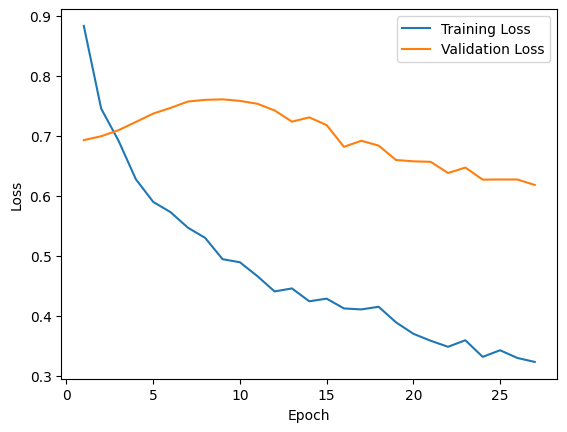

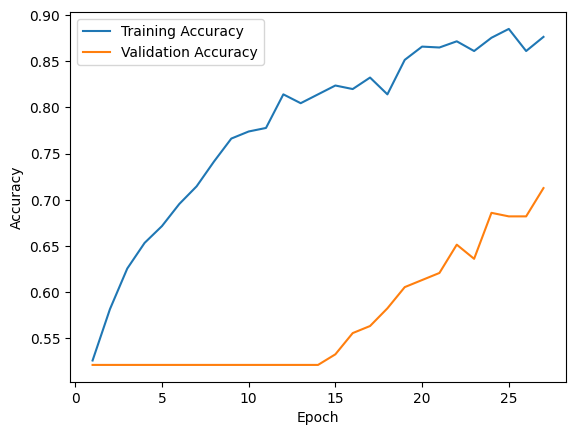

In [17]:
# plot training and validation loss -> pulled from Unit 8 Assignment: Implement a Neural Network for Sentiment Analysis
plt.plot(range(1, num_epochs + 1), history.history['loss'], label='Training Loss')
plt.plot(range(1, num_epochs + 1), history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


plt.plot(range(1, num_epochs + 1), history.history['accuracy'], label='Training Accuracy')
plt.plot(range(1, num_epochs + 1), history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [18]:
# evaluating model performace
loss, accuracy = nn_model.evaluate(X_test_tfidf.toarray(), y_test)
print('Loss: ', str(loss) , 'Accuracy: ', str(accuracy))

18/18 [==============================] - 0s 950us/step - loss: 0.5064 - accuracy: 0.7786
Loss:  0.5064130425453186 Accuracy:  0.7785714268684387


In [19]:
# checking data with high confidence levels
probability_predictions = nn_model.predict(X_test_tfidf.toarray())

print("Predictions for the first 20 examples:")
class_label_predictions=[]
for i in range(20):
    if probability_predictions[i] > .5:
        print(str(i+1) + 'th Example Prediction:\n\tProbability: ' + str(probability_predictions[i]) + '\n\tLabel: ' + str(y_test.to_numpy()[i]))

Predictions for the first 20 examples:
2th Example Prediction:
	Probability: [0.72284174]
	Label: True
4th Example Prediction:
	Probability: [0.9170866]
	Label: True
5th Example Prediction:
	Probability: [0.8965229]
	Label: True
6th Example Prediction:
	Probability: [0.83873355]
	Label: True
8th Example Prediction:
	Probability: [0.92793536]
	Label: True
9th Example Prediction:
	Probability: [0.55102605]
	Label: True
10th Example Prediction:
	Probability: [0.89421785]
	Label: True
11th Example Prediction:
	Probability: [0.86639833]
	Label: True
12th Example Prediction:
	Probability: [0.83352435]
	Label: True
14th Example Prediction:
	Probability: [0.7253936]
	Label: False
17th Example Prediction:
	Probability: [0.80498636]
	Label: True
19th Example Prediction:
	Probability: [0.73954326]
	Label: True
20th Example Prediction:
	Probability: [0.77053547]
	Label: False


In [29]:
# checking reviews
print('Review #18:\n')

print(X_test.to_numpy()[18])

goodReview = True if probability_predictions[18] >= .5 else False
    
print('\nPrediction: Is this a good review? {}\n'.format(goodReview))

print('Actual: Is this a good review? {}\n'.format(y_test.to_numpy()[18]))

Review #18:

This book is without a doubt one of the best in the series of Chicken Soups.  I have purchased several of them and give them out for gifts in the hospital, get well , birthdays and etc.  There is something for everyone in  this book. What a great little gift


Prediction: Is this a good review? True

Actual: Is this a good review? True



In [28]:
# checking reviews
print('Review #377:\n')

print(X_test.to_numpy()[377])

goodReview = True if probability_predictions[377] >= .5 else False
    
print('\nPrediction: Is this a good review? {}\n'.format(goodReview))

print('Actual: Is this a good review? {}\n'.format(y_test.to_numpy()[377]))

Review #377:

Billy Collins's original voice is delightfully accessible, often blending comedy and solemnity in one poem, and always with something new to say. The playful tone of these poems can be misleading; whether he is writing about eating a good plate of Osso Bucco or his favorite museum rooms, there is  always a pathos lingering in the silence after the last line. Most  relieving is the absence of pretentiousness or haughty language. This is  simply, as Robert Bly writes in his introduction to the best American poems  of 1999, Collins's skillful ability to &quot;bring the soul up close to the  thing&quot; in every poem. Books such as &quot;The Art of Drowning&quot;  threaten to change the face and purpose of poetry in the 21st century.  Let's hope there is plenty more to come from Billy Collins


Prediction: Is this a good review? True

Actual: Is this a good review? True



## Conclusion

This project utilized a binary sentiment classifier with TF-IDF and a feedforward neural network with the GELU activation function. My goal was to explore how activation functions may influence model performance, supported by additional research (not included), and I found that changing it from RELU to GELU dramatically affected the hidden layers sizes. The final model achieved a test accuracy of approximately 77.9%, showing an above average performance.

Future improvements could include experimentation with Conv1D layers and researching the data needed to accurately implement them for sentiment analysis, as they can be more effective in some cases of NLP tasks.